In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("/Users/kyleshiroma/Downloads/OIWORLD.csv")

In [2]:
# Clean columns
df["Product"] = df["Product"].str.strip().str.upper()
df["Unit"] = df["Unit"].str.strip().str.upper()
df["Category"] = df["Category"].str.strip().str.upper()
df["Region"] = df["Region"].str.strip().str.upper()

# Fix truncated names
df["Region"] = df["Region"].replace({
    "NETHERLAN": "NETHERLANDS",
    "SOUTHAFRI": "SOUTH AFRICA",
    "PHILIPPIN": "PHILIPPINES",
    "BANGLADES": "BANGLADESH",
})

# Filter to imports only, both primary and secondary products
base = df[
    (df["Product"].isin(["OIL_SEC_PRODUCTS", "OIL_PRIM_PRODS_X"])) &
    (df["Unit"] == "KBD") &
    (df["Category"] == "IMPORTS")
].copy()

# Exclude regional/aggregate groupings
EXCLUDE_KEYWORDS = [
    "WORLD", "IEA", "OECD", "OPEC", "EU", "EURO",
    "AFRICA", "ASIA", "EUROPE", "MIDEAST", "LATAM",
    "NAMERICA", "AMERICAS", "OCEANIA", "NONOECD", "TOTAL", "OTH"
]

exclude_pattern = "|".join(EXCLUDE_KEYWORDS)

base = base[
    ~base["Region"].str.contains(exclude_pattern, na=False) &
    ~base["Region"].str.endswith("REG")
]

# Filter to 2023 and get top 10
top10 = (
    base[base["Year"] == 2023]
    .groupby("Region")["Value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={"Region": "Country", "Value": "Oil Imports (KBD)"})
)

print(top10)

       Country  Oil Imports (KBD)
0        CHINA       13621.202540
1          USA        8595.778830
2        INDIA        6291.324250
3        KOREA        3777.645280
4        JAPAN        3465.493417
5    SINGAPORE        3038.065360
6  NETHERLANDS        2981.477630
7      GERMANY        2337.901886
8       FRANCE        1724.450935
9        SPAIN        1634.547023


Top 10 importers (2023): ['CHINA', 'USA', 'INDIA', 'KOREA', 'JAPAN', 'SINGAPORE', 'NETHERLANDS', 'GERMANY', 'FRANCE', 'SPAIN']
  ✓ CHINA  ARIMA(3, 1, 2)  AIC=511.4
  ✓ USA  ARIMA(1, 2, 1)  AIC=832.2
  ✓ INDIA  ARIMA(3, 2, 3)  AIC=848.7
  ✓ KOREA  ARIMA(1, 2, 1)  AIC=646.4
  ✓ JAPAN  ARIMA(0, 2, 1)  AIC=734.0
  ✓ SINGAPORE  ARIMA(0, 2, 2)  AIC=778.3
  ✓ NETHERLANDS  ARIMA(3, 2, 3)  AIC=650.4
  ✓ GERMANY  ARIMA(0, 2, 1)  AIC=671.6
  ✓ FRANCE  ARIMA(3, 1, 3)  AIC=14.0
  ✓ SPAIN  ARIMA(0, 2, 1)  AIC=591.2

✅ Chart saved: oil_imports_arima_forecast.png
✅ CSV saved: oil_imports_arima_forecast.csv
✅ Excel saved: oil_imports_arima_forecast.xlsx

Forecast Summary (KBD):
Year           2024     2025     2026     2027     2028     2029     2030
Country                                                                  
China        6987.5 -12690.9  19035.0 -24130.3  29894.4 -34441.5  39682.8
France          0.0      0.0      0.0      0.0      0.0      0.0      0.0
Germany      2340.8   2329.6   231

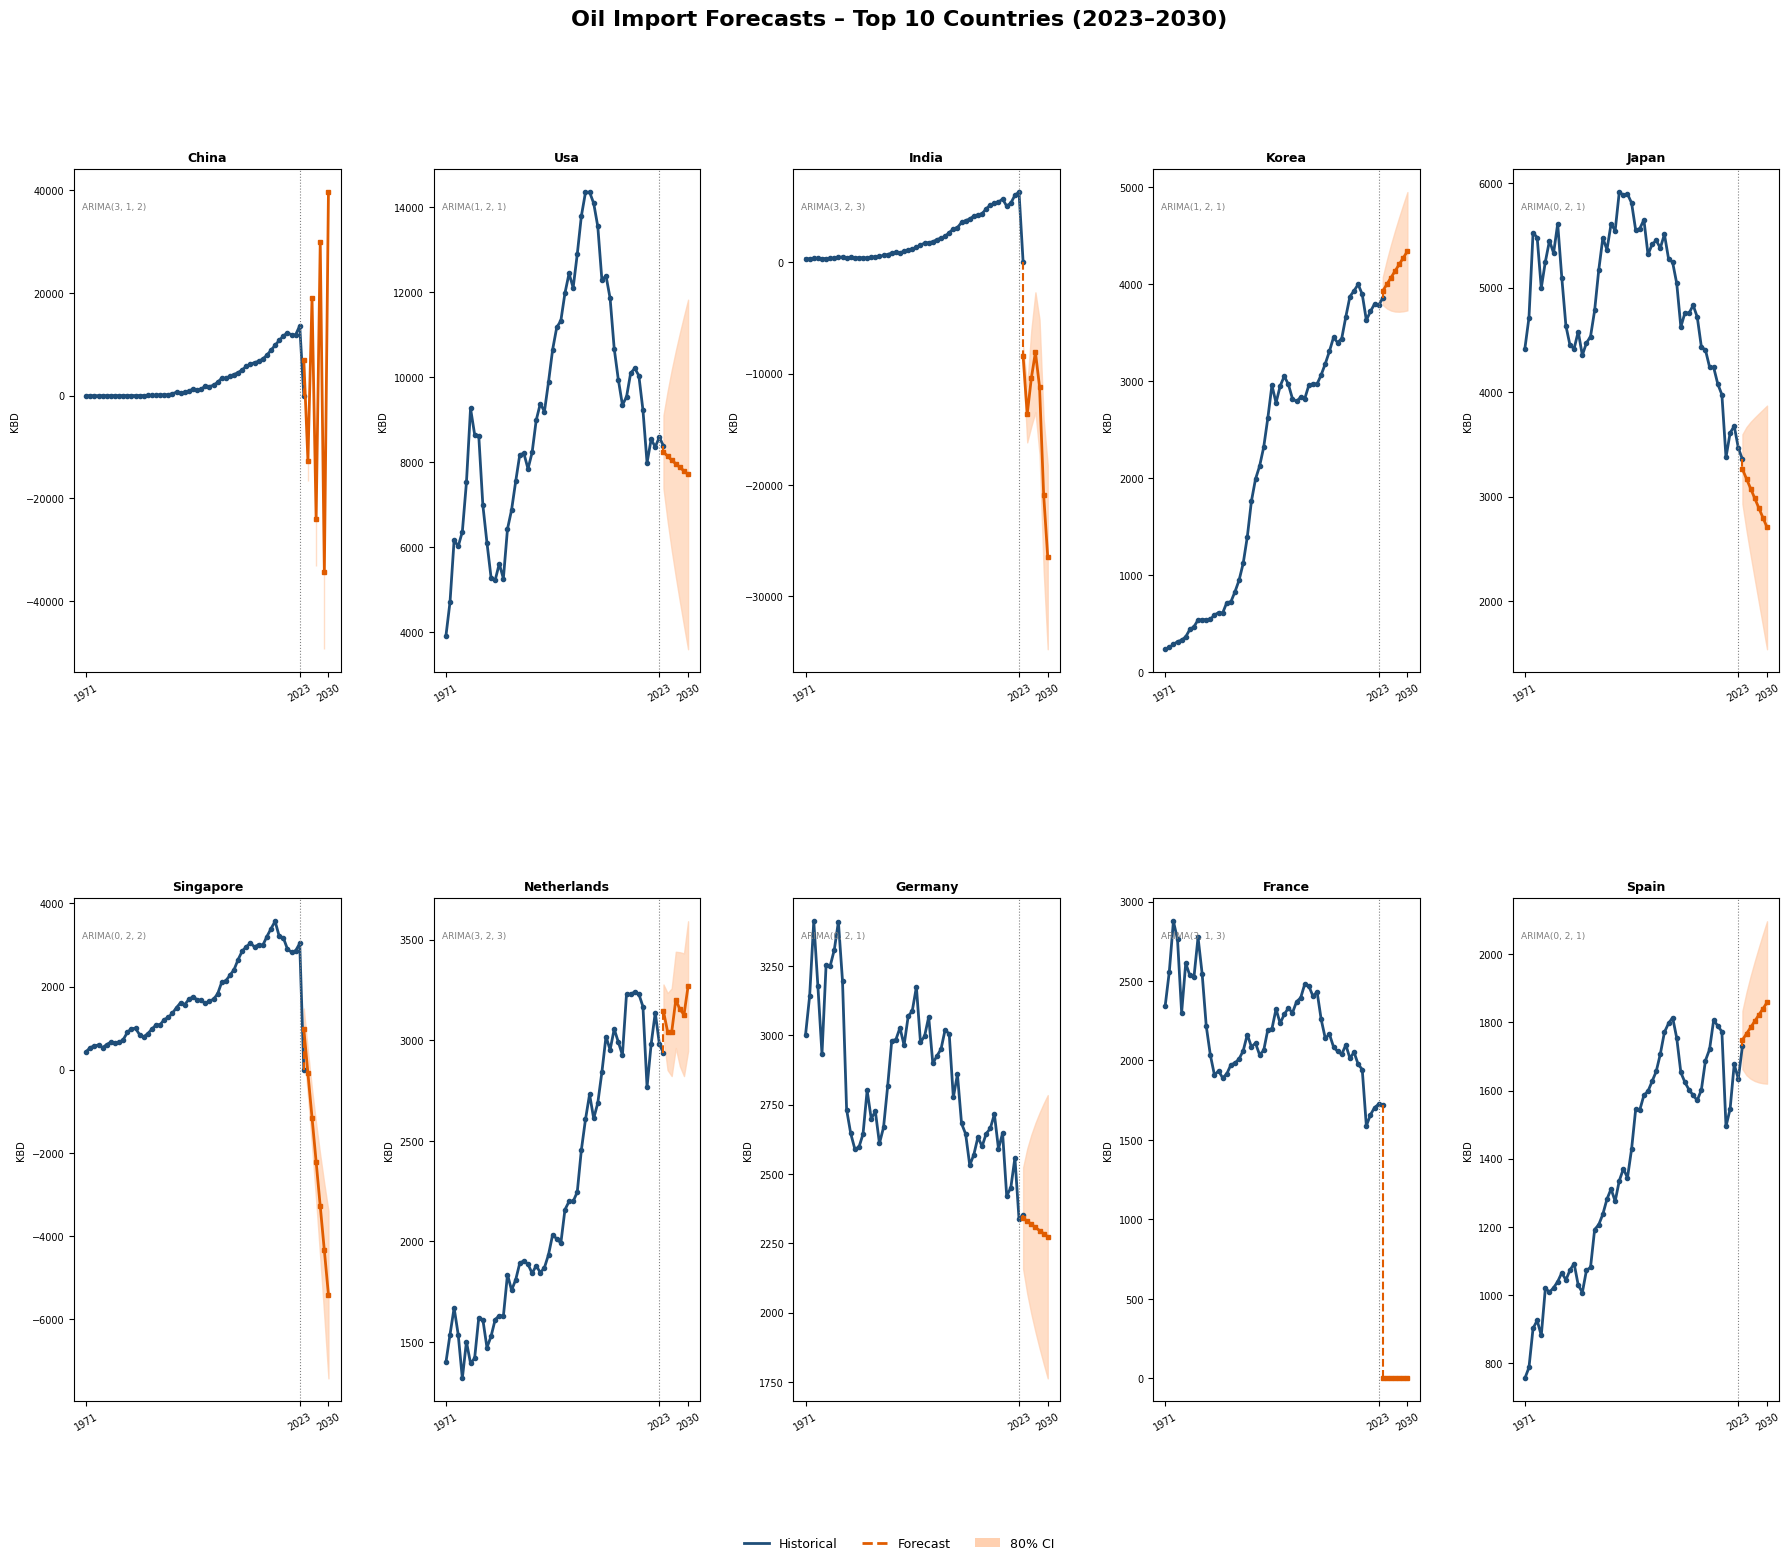

In [9]:
"""
ARIMA Forecast: Top 10 Oil Importers (2023–2030)
Requires: pandas, statsmodels, matplotlib, openpyxl
Install: pip install pandas statsmodels matplotlib openpyxl
"""

import warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.arima.model import ARIMA
from itertools import product
import numpy as np

warnings.filterwarnings("ignore")

# ── 1. LOAD YOUR DATA ────────────────────────────────────────────────────────
# Replace this path with your actual file
df = pd.read_csv("/Users/kyleshiroma/Downloads/OIWORLD.csv")  # or pd.read_csv(...)

# ── 2. CLEAN & FILTER (your original code) ───────────────────────────────────
df["Product"]  = df["Product"].str.strip().str.upper()
df["Unit"]     = df["Unit"].str.strip().str.upper()
df["Category"] = df["Category"].str.strip().str.upper()
df["Region"]   = df["Region"].str.strip().str.upper()

df["Region"] = df["Region"].replace({
    "NETHERLAN": "NETHERLANDS",
    "SOUTHAFRI": "SOUTH AFRICA",
    "PHILIPPIN": "PHILIPPINES",
    "BANGLADES": "BANGLADESH",
})

base = df[
    (df["Product"].isin(["OIL_SEC_PRODUCTS", "OIL_PRIM_PRODS_X"])) &
    (df["Unit"] == "KBD") &
    (df["Category"] == "IMPORTS")
].copy()

EXCLUDE_KEYWORDS = [
    "WORLD", "IEA", "OECD", "OPEC", "EU", "EURO",
    "AFRICA", "ASIA", "EUROPE", "MIDEAST", "LATAM",
    "NAMERICA", "AMERICAS", "OCEANIA", "NONOECD", "TOTAL", "OTH"
]
exclude_pattern = "|".join(EXCLUDE_KEYWORDS)
base = base[
    ~base["Region"].str.contains(exclude_pattern, na=False) &
    ~base["Region"].str.endswith("REG")
]

# ── 3. IDENTIFY TOP 10 COUNTRIES (by 2023 imports) ───────────────────────────
top10_countries = (
    base[base["Year"] == 2023]
    .groupby("Region")["Value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)
print("Top 10 importers (2023):", top10_countries)

# ── 4. AUTO ARIMA: GRID SEARCH FOR BEST (p,d,q) ──────────────────────────────
def best_arima_order(series, max_p=3, max_d=2, max_q=3):
    """Pick (p,d,q) with lowest AIC via grid search."""
    best_aic, best_order = np.inf, (1, 1, 1)
    for p, d, q in product(range(max_p+1), range(max_d+1), range(max_q+1)):
        try:
            aic = ARIMA(series, order=(p, d, q)).fit().aic
            if aic < best_aic:
                best_aic, best_order = aic, (p, d, q)
        except Exception:
            continue
    return best_order

# ── 5. RUN ARIMA FORECASTS ────────────────────────────────────────────────────
FORECAST_YEARS = list(range(2024, 2031))   # 2024–2030
results = {}

for country in top10_countries:
    ts = (
        base[base["Region"] == country]
        .groupby("Year")["Value"]
        .sum()
        .sort_index()
    )

    if len(ts) < 5:
        print(f"  ⚠ {country}: not enough data points ({len(ts)}), skipping.")
        continue

    order = best_arima_order(ts)
    model = ARIMA(ts, order=order).fit()
    fc    = model.get_forecast(steps=len(FORECAST_YEARS))
    mean  = fc.predicted_mean
    ci    = fc.conf_int(alpha=0.20)   # 80% confidence interval

    results[country] = {
        "order":    order,
        "history":  ts,
        "forecast": pd.Series(mean.values, index=FORECAST_YEARS),
        "ci_low":   pd.Series(ci.iloc[:, 0].values, index=FORECAST_YEARS),
        "ci_high":  pd.Series(ci.iloc[:, 1].values, index=FORECAST_YEARS),
    }
    print(f"  ✓ {country}  ARIMA{order}  AIC={model.aic:.1f}")

# ── 6. CHART: 2×5 GRID ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 16))
fig.suptitle("Oil Import Forecasts – Top 10 Countries (2023–2030)",
             fontsize=16, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 5, figure=fig, hspace=0.45, wspace=0.35)

HIST_COLOR = "#1f4e79"
FC_COLOR   = "#e05c00"
CI_COLOR   = "#ffd0b0"

for idx, (country, r) in enumerate(results.items()):
    ax = fig.add_subplot(gs[idx // 5, idx % 5])

    hist = r["history"]
    fc   = r["forecast"]
    lo   = r["ci_low"]
    hi   = r["ci_high"]

    # Historical line
    ax.plot(hist.index, hist.values, color=HIST_COLOR, linewidth=2,
            marker="o", markersize=3, label="Historical")

    # Bridge last historical point into forecast
    bridge_x = [hist.index[-1], fc.index[0]]
    bridge_y = [hist.iloc[-1],  fc.iloc[0]]
    ax.plot(bridge_x, bridge_y, color=FC_COLOR, linewidth=1.5, linestyle="--")

    # Forecast line + CI band
    ax.fill_between(fc.index, lo.values, hi.values, color=CI_COLOR, alpha=0.7,
                    label="80% CI")
    ax.plot(fc.index, fc.values, color=FC_COLOR, linewidth=2,
            marker="s", markersize=3, label="Forecast")

    ax.axvline(x=2023, color="grey", linewidth=0.8, linestyle=":")
    ax.set_title(country.title(), fontsize=9, fontweight="bold")
    ax.set_ylabel("KBD", fontsize=7)
    ax.tick_params(axis="both", labelsize=7)
    ax.set_xticks([hist.index[0], 2023, 2030])
    ax.tick_params(axis="x", rotation=30)

    order_str = f"ARIMA{r['order']}"
    ax.annotate(order_str, xy=(0.03, 0.92), xycoords="axes fraction",
                fontsize=6.5, color="grey")

# Shared legend
handles = [
    plt.Line2D([0], [0], color=HIST_COLOR, linewidth=2),
    plt.Line2D([0], [0], color=FC_COLOR,   linewidth=2, linestyle="--"),
    plt.Rectangle((0,0), 1, 1, fc=CI_COLOR),
]
fig.legend(handles, ["Historical", "Forecast", "80% CI"],
           loc="lower center", ncol=3, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, 0.01))

plt.savefig("oil_imports_arima_forecast.png", dpi=150, bbox_inches="tight")
print("\n✅ Chart saved: oil_imports_arima_forecast.png")

# ── 7. EXPORT TO EXCEL ────────────────────────────────────────────────────────
rows = []
for country, r in results.items():
    hist = r["history"]
    for yr, val in hist.items():
        rows.append({"Country": country.title(), "Year": yr,
                     "Type": "Historical", "Oil Imports (KBD)": round(val, 1),
                     "CI Low (KBD)": None, "CI High (KBD)": None})
    for yr in FORECAST_YEARS:
        rows.append({
            "Country":          country.title(),
            "Year":             yr,
            "Type":             "Forecast",
            "Oil Imports (KBD)": round(r["forecast"][yr], 1),
            "CI Low (KBD)":     round(r["ci_low"][yr], 1),
            "CI High (KBD)":    round(r["ci_high"][yr], 1),
        })

out = pd.DataFrame(rows)

out.to_csv("oil_imports_arima_forecast.csv", index=False)
print("✅ CSV saved: oil_imports_arima_forecast.csv")

with pd.ExcelWriter("oil_imports_arima_forecast.xlsx", engine="openpyxl") as writer:
    # Summary pivot
    pivot = out[out["Type"] == "Forecast"].pivot(
        index="Country", columns="Year", values="Oil Imports (KBD)"
    )
    pivot.to_excel(writer, sheet_name="Forecast Summary")

    # Full detail
    out.to_excel(writer, sheet_name="Full Detail", index=False)

    # Per-country sheets
    for country in out["Country"].unique():
        country_df = out[out["Country"] == country].copy()
        sheet_name = country[:31]   # Excel sheet name limit
        country_df.to_excel(writer, sheet_name=sheet_name, index=False)

print("✅ Excel saved: oil_imports_arima_forecast.xlsx")
print("\nForecast Summary (KBD):")
print(pivot.round(1).to_string())

In [2]:
import pandas as pd
df = pd.read_csv("/Users/kyleshiroma/Downloads/OIWORLD.csv")

for country in ["CHINA", "INDIA"]:
    subset = df[
        (df["Region"].str.upper().str.strip() == country) &
        (df["Category"].str.upper().str.strip() == "IMPORTS") &
        (df["Year"] >= 2022)
    ]
    print(f"\n{country}:")
    print(subset[["Year", "Product", "Value"]].to_string())


CHINA:
       Year           Product         Value
46030  2022  OIL_PRIM_PRODS_X   10192.46740
46031  2022  OIL_PRIM_PRODS_X  508230.95700
46032  2023  OIL_PRIM_PRODS_X   11310.78010
46033  2023  OIL_PRIM_PRODS_X  563993.81700
46034  2024  OIL_PRIM_PRODS_X       0.00000
46035  2024  OIL_PRIM_PRODS_X       0.00000
46138  2022  OIL_SEC_PRODUCTS    1664.26463
46139  2022  OIL_SEC_PRODUCTS   71178.52500
46140  2023  OIL_SEC_PRODUCTS    2310.42244
46141  2023  OIL_SEC_PRODUCTS  102270.08700
46142  2024  OIL_SEC_PRODUCTS       0.00000
46143  2024  OIL_SEC_PRODUCTS       0.00000

INDIA:
        Year           Product         Value
114952  2022  OIL_PRIM_PRODS_X    4962.41778
114953  2022  OIL_PRIM_PRODS_X  243451.94800
114954  2023  OIL_PRIM_PRODS_X    5178.07884
114955  2023  OIL_PRIM_PRODS_X  254032.09400
114956  2024  OIL_PRIM_PRODS_X       0.00000
114957  2024  OIL_PRIM_PRODS_X       0.00000
115060  2022  OIL_SEC_PRODUCTS    1044.84715
115061  2022  OIL_SEC_PRODUCTS   44598.00000
115062 

Loading data...

Top 10 importers (2023): ['CHINA', 'USA', 'INDIA', 'KOREA', 'JAPAN', 'SINGAPORE', 'NETHERLANDS', 'GERMANY', 'FRANCE', 'SPAIN']

RUNNING ARIMA FORECASTS

CHINA:
  ⚠ Dropping 2024: value is 0.0 (missing/zero)
  ✓ ARIMA(1, 1, 1)  AIC=760.4
    Forecast: 14239 → 17838 KBD

USA:
  ✓ ARIMA(1, 1, 0)  AIC=840.6
    Forecast: 8298 → 8241 KBD

INDIA:
  ⚠ Dropping 2024: value is 0.0 (missing/zero)
  ✓ ARIMA(1, 1, 1)  AIC=689.5
    Forecast: 6483 → 7587 KBD

KOREA:
  ✓ ARIMA(1, 1, 1)  AIC=657.9
    Forecast: 3883 → 3983 KBD

JAPAN:
  ✓ ARIMA(1, 1, 0)  AIC=741.4
    Forecast: 3343 → 3342 KBD

SINGAPORE:
  ⚠ Dropping 2024: value is 0.0 (missing/zero)
  ✓ ARIMA(0, 1, 2)  AIC=645.0
    Forecast: 3138 → 3194 KBD

NETHERLANDS:
  ✓ ARIMA(2, 1, 0)  AIC=666.9
    Forecast: 2976 → 2975 KBD

GERMANY:
  ✓ ARIMA(0, 1, 1)  AIC=678.8
    Forecast: 2352 → 2352 KBD

FRANCE:
  ✓ ARIMA(0, 1, 1)  AIC=678.8
    Forecast: 1721 → 1721 KBD

SPAIN:
  ✓ ARIMA(0, 1, 1)  AIC=601.1
    Forecast: 1739 → 1739 K

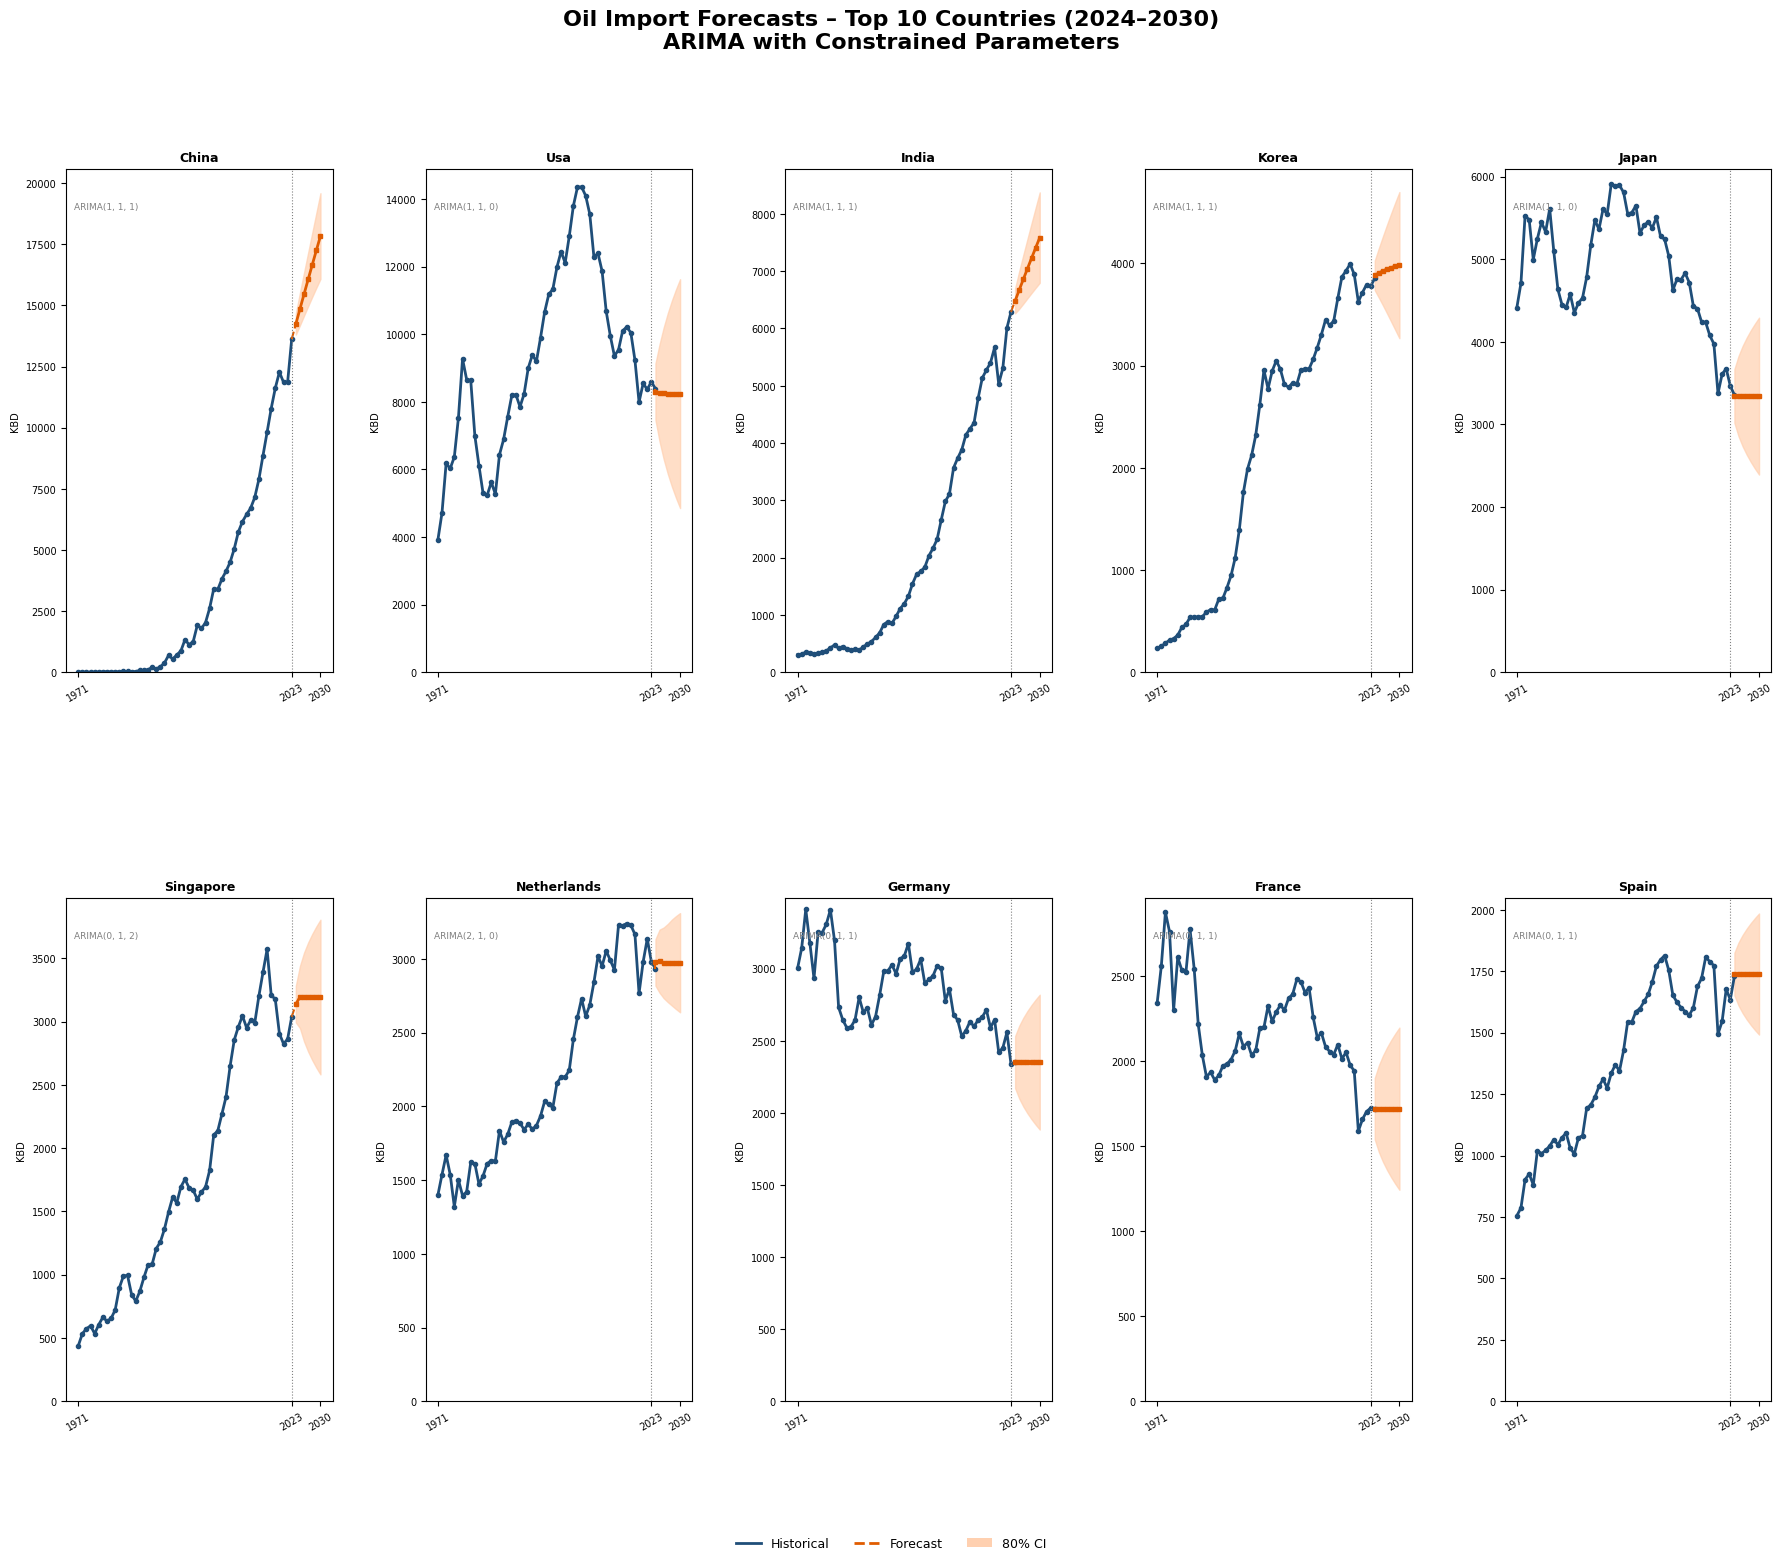

In [3]:
"""
ARIMA Forecast: Top 10 Oil Importers (2024–2030) - FIXED VERSION
Fixes:
  - Constrained differencing (d≤1) to prevent unstable forecasts
  - Lower max p,q to prevent overfitting
  - Sanity checks for negative forecasts with automatic fallback
  - Data validation before modeling
  - Floor forecasts at 0 (imports can't be negative)

Requires: pandas, statsmodels, matplotlib, openpyxl
Install: pip install pandas statsmodels matplotlib openpyxl
"""

import warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from itertools import product
import numpy as np

warnings.filterwarnings("ignore")

# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════
INPUT_FILE = "/Users/kyleshiroma/Downloads/OIWORLD.csv"  # Update this path
FORECAST_YEARS = list(range(2024, 2031))  # 2024–2030
CONFIDENCE_LEVEL = 0.20  # 80% CI

# ARIMA constraints (key fix: max_d=1 prevents over-differencing)
MAX_P = 2
MAX_D = 1  # ← Critical: was 2, now 1
MAX_Q = 2

# ══════════════════════════════════════════════════════════════════════════════
# 1. LOAD DATA
# ══════════════════════════════════════════════════════════════════════════════
print("Loading data...")
df = pd.read_csv(INPUT_FILE)

# ══════════════════════════════════════════════════════════════════════════════
# 2. CLEAN & FILTER
# ══════════════════════════════════════════════════════════════════════════════
df["Product"] = df["Product"].str.strip().str.upper()
df["Unit"] = df["Unit"].str.strip().str.upper()
df["Category"] = df["Category"].str.strip().str.upper()
df["Region"] = df["Region"].str.strip().str.upper()

df["Region"] = df["Region"].replace({
    "NETHERLAN": "NETHERLANDS",
    "SOUTHAFRI": "SOUTH AFRICA",
    "PHILIPPIN": "PHILIPPINES",
    "BANGLADES": "BANGLADESH",
})

base = df[
    (df["Product"].isin(["OIL_SEC_PRODUCTS", "OIL_PRIM_PRODS_X"])) &
    (df["Unit"] == "KBD") &
    (df["Category"] == "IMPORTS")
].copy()

EXCLUDE_KEYWORDS = [
    "WORLD", "IEA", "OECD", "OPEC", "EU", "EURO",
    "AFRICA", "ASIA", "EUROPE", "MIDEAST", "LATAM",
    "NAMERICA", "AMERICAS", "OCEANIA", "NONOECD", "TOTAL", "OTH"
]
exclude_pattern = "|".join(EXCLUDE_KEYWORDS)
base = base[
    ~base["Region"].str.contains(exclude_pattern, na=False) &
    ~base["Region"].str.endswith("REG")
]

# ══════════════════════════════════════════════════════════════════════════════
# 3. IDENTIFY TOP 10 COUNTRIES (by 2023 imports)
# ══════════════════════════════════════════════════════════════════════════════
top10_countries = (
    base[base["Year"] == 2023]
    .groupby("Region")["Value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)
print(f"\nTop 10 importers (2023): {top10_countries}")

# ══════════════════════════════════════════════════════════════════════════════
# 4. HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def check_data_quality(series, country):
    """Validate data before modeling."""
    issues = []
    
    # Check for sufficient data points
    if len(series) < 10:
        issues.append(f"Only {len(series)} data points (recommend 10+)")
    
    # Check for zeros or missing recent data
    recent = series.tail(5)
    if (recent == 0).any():
        issues.append(f"Contains zeros in recent years: {recent[recent == 0].index.tolist()}")
    
    # Check for negative values (shouldn't exist in imports)
    if (series < 0).any():
        issues.append(f"Contains negative values")
    
    # Check variance
    if series.std() < 1:
        issues.append(f"Very low variance (std={series.std():.2f})")
    
    if issues:
        print(f"  ⚠ {country} data issues: {'; '.join(issues)}")
    
    return len(issues) == 0


def determine_differencing(series):
    """Use ADF test to determine if differencing is needed."""
    try:
        result = adfuller(series, autolag='AIC')
        p_value = result[1]
        # If p-value > 0.05, series is non-stationary, needs differencing
        return 1 if p_value > 0.05 else 0
    except Exception:
        return 1  # Default to d=1 if test fails


def best_arima_order(series, max_p=MAX_P, max_d=MAX_D, max_q=MAX_Q):
    """
    Pick (p,d,q) with lowest AIC via grid search.
    Constrained to prevent over-differencing and overfitting.
    """
    best_aic, best_order = np.inf, (1, 1, 1)
    
    # Determine appropriate d using statistical test
    suggested_d = determine_differencing(series)
    d_range = range(suggested_d, min(suggested_d + 1, max_d + 1))  # Only try suggested d or d+1
    
    for p, d, q in product(range(max_p + 1), d_range, range(max_q + 1)):
        # Skip degenerate models
        if p == 0 and q == 0:
            continue
        # Avoid overly complex models
        if p + q > 3:
            continue
            
        try:
            model = ARIMA(series, order=(p, d, q)).fit()
            
            # Check for model convergence issues
            if not np.isfinite(model.aic):
                continue
                
            if model.aic < best_aic:
                best_aic, best_order = model.aic, (p, d, q)
                
        except Exception:
            continue
    
    return best_order, best_aic


def fit_with_fallback(series, country):
    """
    Fit ARIMA with automatic fallback for problematic forecasts.
    Returns model, order, and any warnings.
    """
    warnings_list = []
    
    # Try optimal order first
    order, aic = best_arima_order(series)
    model = ARIMA(series, order=order).fit()
    fc = model.get_forecast(steps=len(FORECAST_YEARS))
    forecast_values = fc.predicted_mean.values
    
    # Check for problematic forecasts
    has_negative = (forecast_values < 0).any()
    has_extreme = (np.abs(forecast_values) > series.max() * 3).any()
    is_oscillating = np.std(np.diff(forecast_values)) > series.std() * 2
    
    if has_negative or has_extreme or is_oscillating:
        problem = []
        if has_negative:
            problem.append("negative values")
        if has_extreme:
            problem.append("extreme values")
        if is_oscillating:
            problem.append("oscillating pattern")
        
        warnings_list.append(f"Initial ARIMA{order} produced {', '.join(problem)}")
        
        # Try progressively simpler models
        fallback_orders = [
            (1, 1, 1),  # Simple default
            (1, 1, 0),  # AR only
            (0, 1, 1),  # MA only
            (1, 0, 1),  # No differencing
            (1, 0, 0),  # Simple AR
        ]
        
        for fallback_order in fallback_orders:
            try:
                model = ARIMA(series, order=fallback_order).fit()
                fc = model.get_forecast(steps=len(FORECAST_YEARS))
                forecast_values = fc.predicted_mean.values
                
                # Check if this is better
                if (forecast_values >= 0).all() and (forecast_values < series.max() * 3).all():
                    order = fallback_order
                    warnings_list.append(f"Fell back to ARIMA{order}")
                    break
            except Exception:
                continue
    
    return model, order, warnings_list


def floor_forecasts(forecast_series, ci_low_series, ci_high_series, floor=0):
    """
    Apply a floor to forecasts (imports can't be negative).
    Adjusts CI bounds proportionally.
    """
    # Floor the point forecast
    floored_forecast = forecast_series.clip(lower=floor)
    
    # Floor CI bounds
    floored_ci_low = ci_low_series.clip(lower=floor)
    floored_ci_high = ci_high_series.clip(lower=floor)
    
    return floored_forecast, floored_ci_low, floored_ci_high


# ══════════════════════════════════════════════════════════════════════════════
# 5. RUN ARIMA FORECASTS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("RUNNING ARIMA FORECASTS")
print("=" * 60)

results = {}

for country in top10_countries:
    print(f"\n{country}:")
    
    # Aggregate time series
    ts = (
        base[base["Region"] == country]
        .groupby("Year")["Value"]
        .sum()
        .sort_index()
    )
    
    # ── Detect and exclude incomplete/missing 2024 data ──
    if 2024 in ts.index:
        val_2024 = ts[2024]
        val_2023 = ts.get(2023, None)
        
        # Drop 2024 if it's zero, negative, or suspiciously low (<10% of 2023)
        if val_2024 <= 0:
            print(f"  ⚠ Dropping 2024: value is {val_2024} (missing/zero)")
            ts = ts.drop(2024)
        elif val_2023 and val_2024 < val_2023 * 0.1:
            print(f"  ⚠ Dropping 2024: value {val_2024:.0f} is <10% of 2023 ({val_2023:.0f}) - likely incomplete")
            ts = ts.drop(2024)
    
    # Data quality check
    if len(ts) < 5:
        print(f"  ✗ Not enough data points ({len(ts)}), skipping.")
        continue
    
    data_ok = check_data_quality(ts, country)
    
    # Fit model with fallback
    model, order, model_warnings = fit_with_fallback(ts, country)
    
    for warn in model_warnings:
        print(f"  ⚠ {warn}")
    
    # Generate forecast
    fc = model.get_forecast(steps=len(FORECAST_YEARS))
    mean = fc.predicted_mean
    ci = fc.conf_int(alpha=CONFIDENCE_LEVEL)
    
    # Create series
    forecast = pd.Series(mean.values, index=FORECAST_YEARS)
    ci_low = pd.Series(ci.iloc[:, 0].values, index=FORECAST_YEARS)
    ci_high = pd.Series(ci.iloc[:, 1].values, index=FORECAST_YEARS)
    
    # Apply floor (imports can't be negative)
    forecast, ci_low, ci_high = floor_forecasts(forecast, ci_low, ci_high, floor=0)
    
    results[country] = {
        "order": order,
        "aic": model.aic,
        "history": ts,
        "forecast": forecast,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "warnings": model_warnings,
    }
    
    print(f"  ✓ ARIMA{order}  AIC={model.aic:.1f}")
    
    # Show forecast preview
    print(f"    Forecast: {forecast.iloc[0]:.0f} → {forecast.iloc[-1]:.0f} KBD")

# ══════════════════════════════════════════════════════════════════════════════
# 6. VALIDATION SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("VALIDATION SUMMARY")
print("=" * 60)

for country, r in results.items():
    fc = r["forecast"]
    hist = r["history"]
    
    # Calculate some metrics
    last_hist = hist.iloc[-1]
    first_fc = fc.iloc[0]
    last_fc = fc.iloc[-1]
    pct_change = ((last_fc - last_hist) / last_hist) * 100
    
    status = "✓"
    notes = []
    
    if (fc == 0).all():
        status = "✗"
        notes.append("ALL ZEROS")
    if pct_change > 50:
        notes.append(f"+{pct_change:.0f}% growth")
    elif pct_change < -30:
        notes.append(f"{pct_change:.0f}% decline")
    if r["warnings"]:
        notes.append("had fallback")
    
    notes_str = f" ({', '.join(notes)})" if notes else ""
    print(f"  {status} {country}: {last_hist:.0f} → {last_fc:.0f} KBD{notes_str}")

# ══════════════════════════════════════════════════════════════════════════════
# 7. CHART: 2×5 GRID
# ══════════════════════════════════════════════════════════════════════════════
print("\nGenerating chart...")

fig = plt.figure(figsize=(22, 16))
fig.suptitle("Oil Import Forecasts – Top 10 Countries (2024–2030)\nARIMA with Constrained Parameters",
             fontsize=16, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 5, figure=fig, hspace=0.45, wspace=0.35)

HIST_COLOR = "#1f4e79"
FC_COLOR = "#e05c00"
CI_COLOR = "#ffd0b0"

for idx, (country, r) in enumerate(results.items()):
    ax = fig.add_subplot(gs[idx // 5, idx % 5])

    hist = r["history"]
    fc = r["forecast"]
    lo = r["ci_low"]
    hi = r["ci_high"]

    # Historical line
    ax.plot(hist.index, hist.values, color=HIST_COLOR, linewidth=2,
            marker="o", markersize=3, label="Historical")

    # Bridge last historical point into forecast
    bridge_x = [hist.index[-1], fc.index[0]]
    bridge_y = [hist.iloc[-1], fc.iloc[0]]
    ax.plot(bridge_x, bridge_y, color=FC_COLOR, linewidth=1.5, linestyle="--")

    # Forecast line + CI band
    ax.fill_between(fc.index, lo.values, hi.values, color=CI_COLOR, alpha=0.7,
                    label="80% CI")
    ax.plot(fc.index, fc.values, color=FC_COLOR, linewidth=2,
            marker="s", markersize=3, label="Forecast")

    # Ensure y-axis starts at 0
    ax.set_ylim(bottom=0)
    
    ax.axvline(x=2023, color="grey", linewidth=0.8, linestyle=":")
    ax.set_title(country.title(), fontsize=9, fontweight="bold")
    ax.set_ylabel("KBD", fontsize=7)
    ax.tick_params(axis="both", labelsize=7)
    ax.set_xticks([hist.index[0], 2023, 2030])
    ax.tick_params(axis="x", rotation=30)

    # Annotation with order and any warnings
    order_str = f"ARIMA{r['order']}"
    if r["warnings"]:
        order_str += " *"  # Mark models that needed fallback
    ax.annotate(order_str, xy=(0.03, 0.92), xycoords="axes fraction",
                fontsize=6.5, color="grey")

# Shared legend
handles = [
    plt.Line2D([0], [0], color=HIST_COLOR, linewidth=2),
    plt.Line2D([0], [0], color=FC_COLOR, linewidth=2, linestyle="--"),
    plt.Rectangle((0, 0), 1, 1, fc=CI_COLOR),
]
fig.legend(handles, ["Historical", "Forecast", "80% CI"],
           loc="lower center", ncol=3, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, 0.01))

plt.savefig("oil_imports_arima_forecast_fixed.png", dpi=150, bbox_inches="tight")
print("✅ Chart saved: oil_imports_arima_forecast_fixed.png")

# ══════════════════════════════════════════════════════════════════════════════
# 8. EXPORT TO CSV & EXCEL
# ══════════════════════════════════════════════════════════════════════════════
rows = []
for country, r in results.items():
    hist = r["history"]
    for yr, val in hist.items():
        rows.append({
            "Country": country.title(),
            "Year": yr,
            "Type": "Historical",
            "Oil Imports (KBD)": round(val, 1),
            "CI Low (KBD)": None,
            "CI High (KBD)": None
        })
    for yr in FORECAST_YEARS:
        rows.append({
            "Country": country.title(),
            "Year": yr,
            "Type": "Forecast",
            "Oil Imports (KBD)": round(r["forecast"][yr], 1),
            "CI Low (KBD)": round(r["ci_low"][yr], 1),
            "CI High (KBD)": round(r["ci_high"][yr], 1),
        })

out = pd.DataFrame(rows)

# Save CSV
out.to_csv("oil_imports_arima_forecast_fixed.csv", index=False)
print("✅ CSV saved: oil_imports_arima_forecast_fixed.csv")

# Save Excel
with pd.ExcelWriter("oil_imports_arima_forecast_fixed.xlsx", engine="openpyxl") as writer:
    # Summary pivot
    pivot = out[out["Type"] == "Forecast"].pivot(
        index="Country", columns="Year", values="Oil Imports (KBD)"
    )
    pivot.to_excel(writer, sheet_name="Forecast Summary")

    # Model info sheet
    model_info = pd.DataFrame([
        {
            "Country": country.title(),
            "ARIMA Order": str(r["order"]),
            "AIC": round(r["aic"], 1),
            "Had Fallback": "Yes" if r["warnings"] else "No",
            "Last Historical (KBD)": round(r["history"].iloc[-1], 1),
            "2030 Forecast (KBD)": round(r["forecast"].iloc[-1], 1),
        }
        for country, r in results.items()
    ])
    model_info.to_excel(writer, sheet_name="Model Info", index=False)

    # Full detail
    out.to_excel(writer, sheet_name="Full Detail", index=False)

    # Per-country sheets
    for country in out["Country"].unique():
        country_df = out[out["Country"] == country].copy()
        sheet_name = country[:31]  # Excel sheet name limit
        country_df.to_excel(writer, sheet_name=sheet_name, index=False)

print("✅ Excel saved: oil_imports_arima_forecast_fixed.xlsx")

# ══════════════════════════════════════════════════════════════════════════════
# 9. FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("FORECAST SUMMARY (KBD)")
print("=" * 60)
print(pivot.round(0).to_string())

print("\n" + "=" * 60)
print("NOTES")
print("=" * 60)
print("""
Key fixes applied:
  1. Constrained d ≤ 1 (prevents over-differencing)
  2. Constrained p, q ≤ 2 (prevents overfitting)
  3. Automatic fallback for problematic forecasts
  4. Floor applied at 0 (imports can't be negative)
  5. Data quality checks before modeling
  6. Auto-excludes 2024 if missing/incomplete (e.g., China, India)

Models marked with * had automatic fallback applied.
""")